# Broadband qubit spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal06_qubit_spectroscopy_full_bandwidth import BroadbandQubitSpectroscopy

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If use None, it will not change the value already in the hardware
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "broadband_qubit_spectroscopy"

QUBITS = ["q1"]
FREQUENCY_CENTER = None  # None: use each qubit's own f01 from the device config
FREQUENCY_WIDTH = 200e6
FREQUENCY_POINTS = 401
MAXIMUM_BRANCH_WIDTH = 400e6
REPETITIONS = 300
DRIVE_AMPLITUDE = 0.05
DRIVE_DURATION = 20e-6

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
RESTORE_DRIVE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config   # Use None if param persisting is not required

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = BroadbandQubitSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Branch plan

In [4]:
for qubit in experiment.qubits:
    center = (
        float(qubit.clock_freqs.f01)
        if FREQUENCY_CENTER is None
        else FREQUENCY_CENTER
    )
    branches = experiment.plan_branches(
        frequency_center=center,
        frequency_width=FREQUENCY_WIDTH,
        frequency_points=FREQUENCY_POINTS,
        maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    )
    print(f"{qubit.name} (center {center / 1e9:.6f} GHz):")
    for branch in branches:
        print(
            f"  Branch {branch.index + 1}: "
            f"{branch.start / 1e9:.6f}-{branch.stop / 1e9:.6f} GHz, "
            f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
            f"{branch.points} points"
        )

q1 (center 3.530843 GHz):
  Branch 1: 3.430843-3.630843 GHz, LO 3.530843 GHz, 401 points


## Measurement

In [5]:

dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    restore_drive_lo_frequency=RESTORE_DRIVE_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 13kB
Dimensions:           (acq_index_S21_q1: 401)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 3kB 3.431e+09 ... 3.631e+09
  * acq_index_S21_q1  (acq_index_S21_q1) int64 3kB 0 1 2 3 4 ... 397 398 399 400
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 6kB (-0.00048406772255897...
Attributes:
    tuid:     20260915-071124-516-4cb365

## Optional: view the compiled pulse schedule

`build_schedule()` wraps the sweep in a hardware loop that compiles to a single opaque `LoopOperation`, which `plot_pulse_diagram()` can't render. `preview_pulse_schedule()` builds a small loop-free stand-in instead, just for visual inspection of the pulse shape.

In [6]:
experiment.preview_pulse_schedule(
    frequency_center=FREQUENCY_CENTER,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
)

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


## Optional: Simulated data

In [7]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     qubit_frequency=5.444e9,
#     linewidth=10e6,
#     phase_offset=0.0,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [8]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

q1: f01 = 3.540455950 GHz, linewidth = 35.592 MHz


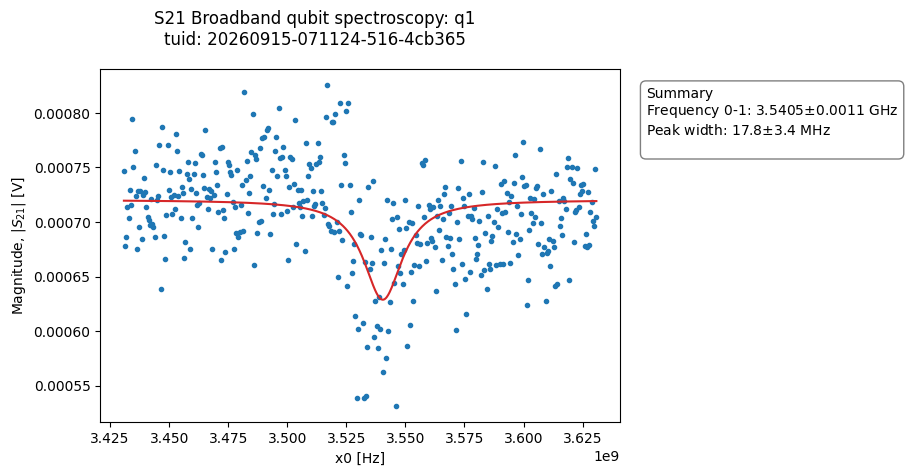

In [9]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [11]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [10]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [38]:
from qcodes.instrument import Instrument

Instrument.close_all()